# 04 — Link Prediction Baseline

**Coverage**: Step 10 (Heuristics) · Step 11 (Spectral Embedding) · Step 12 (Link Prediction) · Step 13 (Evaluation)

**Goal**: Build a progression of link-prediction models for the Compound–treats–Disease (CtD) task:
1. Simple graph heuristics (Common Neighbors, Jaccard)
2. Spectral embedding pipeline on the C-G-D subgraph
3. Link prediction via cosine similarity and a logistic regression classifier
4. Evaluation with AUROC, AUPRC, and top-k retrieval

Builds on interfaces from `utils.py` established in notebooks 01–03.

In [1]:
from __future__ import annotations
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

from utils import load_hetnet, setup_plot_style

setup_plot_style()

In [2]:
hetnet = load_hetnet()

# Node sets and name lookup (same pattern as 03_compound_disease)
compound_ids = set(n['identifier'] for n in hetnet['nodes'] if n['kind'] == 'Compound')
disease_ids  = set(n['identifier'] for n in hetnet['nodes'] if n['kind'] == 'Disease')
name_lookup  = {(n['kind'], n['identifier']): n['name'] for n in hetnet['nodes']}

# Known CtD pairs
ctd_pairs: set[tuple] = set()
for e in hetnet['edges']:
    if e['kind'] == 'treats':
        sk, si = e['source_id']
        tk, ti = e['target_id']
        if sk == 'Compound' and tk == 'Disease':
            ctd_pairs.add((si, ti))
        elif sk == 'Disease' and tk == 'Compound':
            ctd_pairs.add((ti, si))
ctd_pairs = frozenset(ctd_pairs)

max_pairs = len(compound_ids) * len(disease_ids)
print(f'Compounds : {len(compound_ids):,}')
print(f'Diseases  : {len(disease_ids):,}')
print(f'CtD pairs : {len(ctd_pairs):,}  (density {len(ctd_pairs)/max_pairs:.4%})')
print(f'Random AUPRC baseline: {len(ctd_pairs)/max_pairs:.4f}')

Compounds : 1,552
Diseases  : 137
CtD pairs : 755  (density 0.3551%)
Random AUPRC baseline: 0.0036


In [3]:
# Build undirected C-G-D simple graph — exclude 'treats' edges to avoid label leakage.
# CtD pairs are already captured in ctd_pairs; keeping them in H would let heuristics
# and spectral embeddings read the labels indirectly via D-D resembles / C-C resembles paths.
CGD_KINDS = {'Compound', 'Gene', 'Disease'}

H = nx.Graph()
for n in hetnet['nodes']:
    if n['kind'] in CGD_KINDS:
        H.add_node((n['kind'], n['identifier']), kind=n['kind'], name=n['name'])
for e in hetnet['edges']:
    if e['kind'] == 'treats':          # target relation — excluded from feature graph
        continue
    sk, si = e['source_id']
    tk, ti = e['target_id']
    if sk in CGD_KINDS and tk in CGD_KINDS:
        H.add_edge((sk, si), (tk, ti))

print(f'C-G-D subgraph (no CtD edges): {H.number_of_nodes():,} nodes, {H.number_of_edges():,} edges')

C-G-D subgraph (no CtD edges): 22,634 nodes, 557,529 edges


---
## 1 · Simple Heuristics

For a (Compound, Disease) pair, heuristic scores are derived from shared neighbourhood structure in the C-G-D graph.

We use the sparse matrix identity:
- **Common Neighbors**: `CN[c,d] = (A_C @ A_D.T)[c,d]`
- **Jaccard**: `CN[c,d] / (deg(c) + deg(d) - CN[c,d])`

This avoids an explicit O(|C|·|D|) loop and runs in milliseconds.

In [4]:
# Ordered node lists for reproducible indexing
all_nodes   = sorted(H.nodes())
node_to_idx = {n: i for i, n in enumerate(all_nodes)}

A = nx.to_scipy_sparse_array(H, nodelist=all_nodes, format='csr', dtype=float)

# Compound and Disease index arrays
c_nodes = sorted(n for n in H.nodes() if n[0] == 'Compound')
d_nodes = sorted(n for n in H.nodes() if n[0] == 'Disease')
c_idx   = [node_to_idx[n] for n in c_nodes]
d_idx   = [node_to_idx[n] for n in d_nodes]
c_ids   = [n[1] for n in c_nodes]
d_ids   = [n[1] for n in d_nodes]

# Submatrices: rows = compounds/diseases, cols = all nodes
A_C = A[c_idx, :]  # (n_compounds, n_nodes)
A_D = A[d_idx, :]  # (n_diseases,  n_nodes)

# Common Neighbors matrix (1552 x 137)
CN = (A_C @ A_D.T).toarray()

print(f'Adjacency matrix : {A.shape}, {A.nnz:,} non-zeros')
print(f'CN matrix        : {CN.shape}')
print(f'Reachable pairs  : {(CN > 0).sum():,} / {CN.size:,} ({(CN>0).sum()/CN.size:.2%})')
print(f'Max common neighbors: {CN.max():.0f}')

Adjacency matrix : (22634, 22634), 1,115,058 non-zeros
CN matrix        : (1552, 137)
Reachable pairs  : 50,735 / 212,624 (23.86%)
Max common neighbors: 106


In [5]:
# Jaccard similarity
deg     = np.array(A.sum(axis=1)).flatten()
deg_C   = deg[c_idx]                                         # (n_compounds,)
deg_D   = deg[d_idx]                                         # (n_diseases,)
union   = deg_C[:, None] + deg_D[None, :] - CN              # (n_compounds, n_diseases)
jaccard = CN / np.maximum(union, 1.0)

print(f'Jaccard: max={jaccard.max():.4f},  non-zero pairs: {(jaccard>0).sum():,}')

Jaccard: max=0.1429,  non-zero pairs: 50,735


In [6]:
# Ground-truth matrix (n_compounds x n_diseases)
c_to_ci = {cid: ci for ci, cid in enumerate(c_ids)}
d_to_di = {did: di for di, did in enumerate(d_ids)}
y_true_mat = np.zeros((len(c_ids), len(d_ids)), dtype=int)
for cid, did in ctd_pairs:
    if cid in c_to_ci and did in d_to_di:
        y_true_mat[c_to_ci[cid], d_to_di[did]] = 1

y_true_flat = y_true_mat.flatten()
cn_flat     = CN.flatten()
jac_flat    = jaccard.flatten()

heuristic_metrics = []
for name, scores in [('Common Neighbors', cn_flat), ('Jaccard', jac_flat)]:
    heuristic_metrics.append({
        'Method': name,
        'AUROC':  round(roc_auc_score(y_true_flat, scores), 4),
        'AUPRC':  round(average_precision_score(y_true_flat, scores), 4),
    })

print(f'Random baseline AUPRC: {y_true_flat.mean():.4f}')
pd.DataFrame(heuristic_metrics)

Random baseline AUPRC: 0.0036


,Method,AUROC,AUPRC
0,Common Neighbors,0.8167,0.0296
1,Jaccard,0.8045,0.0178


In [7]:
K = 20
top_idx = np.argsort(cn_flat)[::-1][:K]
rows = []
for rank, idx in enumerate(top_idx, 1):
    ci, di = divmod(int(idx), len(d_ids))
    cid, did = c_ids[ci], d_ids[di]
    rows.append({
        'Rank':      rank,
        'Compound':  name_lookup.get(('Compound', cid), cid),
        'Disease':   name_lookup.get(('Disease',  did), did),
        'CN score':  int(CN[ci, di]),
        'Known CtD': '✓' if (cid, did) in ctd_pairs else '',
    })
print(f'Top-{K} predictions — Common Neighbors')
pd.DataFrame(rows)

Top-20 predictions — Common Neighbors


,Rank,Compound,Disease,CN score,Known CtD
0,1,Teniposide,IgA glomerulonephritis,106,
1,2,Menadione,IgA glomerulonephritis,105,
2,3,Cyclosporine,IgA glomerulonephritis,105,
3,4,Cyclosporine,breast cancer,105,
4,5,Teniposide,breast cancer,102,
5,6,Gemcitabine,breast cancer,101,✓
6,7,Niclosamide,IgA glomerulonephritis,101,
7,8,Crizotinib,breast cancer,98,
8,9,Dabrafenib,breast cancer,94,
9,10,Niclosamide,breast cancer,93,


---
## 2 · Spectral Embedding Pipeline

Steps:
1. Find connected components — spectral methods require a connected graph
2. Build sparse adjacency matrix for the largest connected component (LCC)
3. Compute symmetric normalized Laplacian: $L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$
4. Plot eigenvalues and spectral gaps to identify cluster structure
5. Extract first $k$ non-trivial eigenvectors as node embeddings

Total components : 2712
LCC size         : 19,915 nodes  (88.0% of C-G-D graph)
  Compounds : 1,517  (97.7%)
  Diseases  : 136   (99.3%)
  Genes     : 18,262


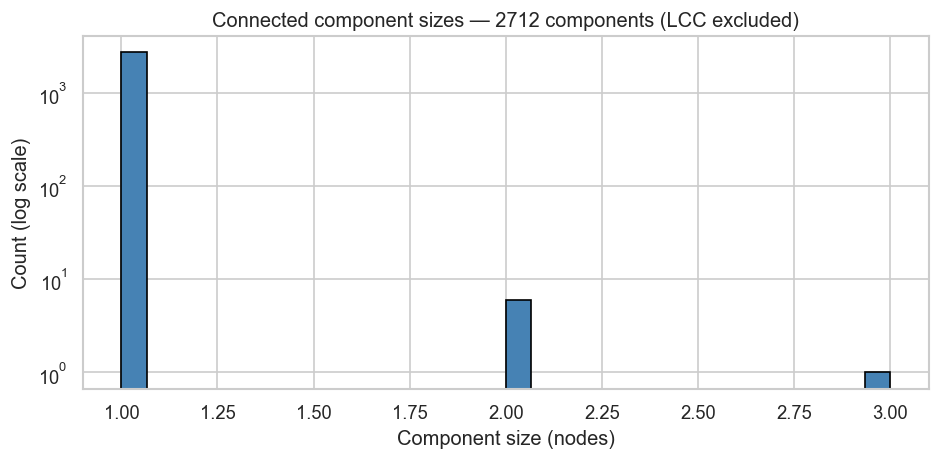

In [8]:
components = sorted(nx.connected_components(H), key=len, reverse=True)
lcc_nodes  = components[0]

lcc_c = sum(1 for n in lcc_nodes if n[0] == 'Compound')
lcc_d = sum(1 for n in lcc_nodes if n[0] == 'Disease')
lcc_g = sum(1 for n in lcc_nodes if n[0] == 'Gene')

print(f'Total components : {len(components)}')
print(f'LCC size         : {len(lcc_nodes):,} nodes  ({len(lcc_nodes)/H.number_of_nodes():.1%} of C-G-D graph)')
print(f'  Compounds : {lcc_c:,}  ({lcc_c/len(compound_ids):.1%})')
print(f'  Diseases  : {lcc_d:,}   ({lcc_d/len(disease_ids):.1%})')
print(f'  Genes     : {lcc_g:,}')

sizes = [len(c) for c in components]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes[1:], bins=30, color='steelblue', edgecolor='black', log=True)
ax.set_xlabel('Component size (nodes)')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'Connected component sizes — {len(components)} components (LCC excluded)')
plt.tight_layout()
plt.show()

In [9]:
H_lcc        = H.subgraph(lcc_nodes).copy()
lcc_node_list = sorted(H_lcc.nodes())
lcc_idx       = {n: i for i, n in enumerate(lcc_node_list)}
n_lcc         = len(lcc_node_list)

A_lcc = nx.to_scipy_sparse_array(H_lcc, nodelist=lcc_node_list, format='csr', dtype=float)

# D^{-1/2}
degree_lcc = np.array(A_lcc.sum(axis=1)).flatten()
d_inv_sqrt = np.where(degree_lcc > 0, degree_lcc ** -0.5, 0.0)
D_inv_sqrt = sp.diags(d_inv_sqrt)

# Symmetric normalized Laplacian
L_sym = (sp.eye(n_lcc, format='csr') - D_inv_sqrt @ A_lcc @ D_inv_sqrt).tocsr()

print(f'LCC adjacency    : {n_lcc:,} x {n_lcc:,},  {A_lcc.nnz:,} non-zeros')
print(f'L_sym computed   : shape {L_sym.shape}')

LCC adjacency    : 19,915 x 19,915,  1,115,040 non-zeros
L_sym computed   : shape (19915, 19915)


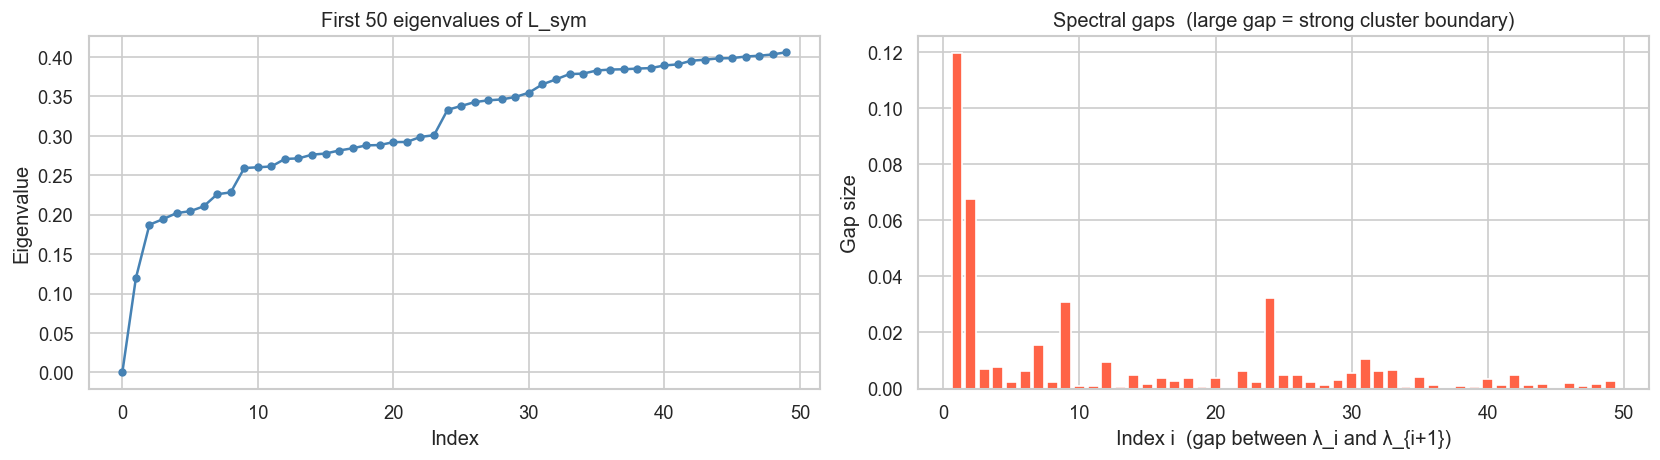

λ₀ (≈0 for connected graph): 2.28e-16
λ₁                         : 0.1196
Largest gap at index        : 1  (λ=0.1196)


In [10]:
K_EIG = 50
eigenvalues, eigenvectors = spla.eigsh(L_sym, k=K_EIG, which='SM')
order        = np.argsort(eigenvalues)
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(eigenvalues, 'o-', markersize=4, color='steelblue')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title(f'First {K_EIG} eigenvalues of L_sym')

gaps = np.diff(eigenvalues)
axes[1].bar(range(1, len(gaps) + 1), gaps, color='tomato')
axes[1].set_xlabel('Index i  (gap between λ_i and λ_{i+1})')
axes[1].set_ylabel('Gap size')
axes[1].set_title('Spectral gaps  (large gap = strong cluster boundary)')

plt.tight_layout()
plt.show()

print(f'λ₀ (≈0 for connected graph): {eigenvalues[0]:.2e}')
print(f'λ₁                         : {eigenvalues[1]:.4f}')
print(f'Largest gap at index        : {gaps.argmax() + 1}  '
      f'(λ={eigenvalues[gaps.argmax() + 1]:.4f})')

In [11]:
# Select D_EMBED from the spectral gap: use all dimensions up to (and including)
# the largest gap, with a floor of 4 and a ceiling of 32.
D_EMBED = min(max(int(gaps.argmax()) + 1, 4), 32)
print(f'Spectral gap selects D_EMBED = {D_EMBED}  (largest gap at index {gaps.argmax()})')

emb_matrix = eigenvectors[:, 1:D_EMBED + 1]    # skip trivial λ₀ ≈ 0
emb_matrix = normalize(emb_matrix, norm='l2')   # L2-normalize rows

compound_emb: dict[str, np.ndarray] = {}
disease_emb:  dict[str, np.ndarray] = {}
for node, idx in lcc_idx.items():
    kind, ident = node
    if kind == 'Compound':
        compound_emb[ident] = emb_matrix[idx]
    elif kind == 'Disease':
        disease_emb[ident]  = emb_matrix[idx]

print(f'Embedding dim : {D_EMBED}')
print(f'Compounds with embeddings : {len(compound_emb):,} / {len(compound_ids):,} '
      f'({len(compound_emb)/len(compound_ids):.1%})')
print(f'Diseases  with embeddings : {len(disease_emb):,}  / {len(disease_ids):,}  '
      f'({len(disease_emb)/len(disease_ids):.1%})')

Spectral gap selects D_EMBED = 4  (largest gap at index 0)
Embedding dim : 4
Compounds with embeddings : 1,517 / 1,552 (97.7%)
Diseases  with embeddings : 136  / 137  (99.3%)


---
## 3 · Link Prediction

Two approaches using the spectral embeddings:
- **Cosine similarity** — unsupervised; score = dot product of L2-normalized embeddings
- **Logistic regression** — supervised; features = concatenated embeddings `[emb_c ‖ emb_d]`

In [12]:
# Ordered lists of compounds/diseases that have embeddings (in LCC)
emb_c_ids = sorted(compound_emb.keys())
emb_d_ids = sorted(disease_emb.keys())

E_C = np.array([compound_emb[c] for c in emb_c_ids])  # (n_c, D_EMBED)
E_D = np.array([disease_emb[d]  for d in emb_d_ids])  # (n_d, D_EMBED)

# Cosine similarity (rows already L2-normalized)
cos_sim = E_C @ E_D.T   # (n_c, n_d)

# Ground truth for LCC-covered pairs
y_emb = np.array([[1 if (c, d) in ctd_pairs else 0
                   for d in emb_d_ids]
                  for c in emb_c_ids], dtype=int).flatten()

cos_flat  = cos_sim.flatten()
auroc_cos = roc_auc_score(y_emb, cos_flat)
auprc_cos = average_precision_score(y_emb, cos_flat)

print(f'LCC coverage  : {len(emb_c_ids)} C x {len(emb_d_ids)} D = {len(emb_c_ids)*len(emb_d_ids):,} pairs')
print(f'Positives     : {y_emb.sum():.0f} / {len(ctd_pairs)} ({y_emb.sum()/len(ctd_pairs):.1%} of all CtD)')
print(f'AUROC (cosine): {auroc_cos:.4f}')
print(f'AUPRC (cosine): {auprc_cos:.4f}')

LCC coverage  : 1517 C x 136 D = 206,312 pairs
Positives     : 755 / 755 (100.0% of all CtD)
AUROC (cosine): 0.6167
AUPRC (cosine): 0.0054


In [13]:
# Build feature matrix: [emb_c || emb_d] for all LCC pairs
pair_list = [(c, d) for c in emb_c_ids for d in emb_d_ids]
X = np.array([np.concatenate([compound_emb[c], disease_emb[d]]) for c, d in pair_list])
y = np.array([1 if (c, d) in ctd_pairs else 0 for c, d in pair_list])

print(f'Feature matrix : {X.shape}  (pos: {y.sum()}, neg: {(y==0).sum()})')

# Stratified 80/20 train-test split
idx_all = np.arange(len(pair_list))
idx_train, idx_test = train_test_split(idx_all, test_size=0.2, stratify=y, random_state=42)

# Logistic regression with balanced class weights to handle 0.36% imbalance
clf = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)
clf.fit(X[idx_train], y[idx_train])

y_prob_test = clf.predict_proba(X[idx_test])[:, 1]
auroc_lr = roc_auc_score(y[idx_test], y_prob_test)
auprc_lr = average_precision_score(y[idx_test], y_prob_test)

# Scores on all pairs (for top-k)
y_prob_all = clf.predict_proba(X)[:, 1]

print(f'Logistic Regression (test set):')
print(f'  AUROC : {auroc_lr:.4f}')
print(f'  AUPRC : {auprc_lr:.4f}')

Feature matrix : (206312, 8)  (pos: 755, neg: 205557)


Logistic Regression (test set):
  AUROC : 0.6811
  AUPRC : 0.0097


---
## 4 · Evaluation

In [14]:
# Restrict heuristic scores to LCC pairs for a fair apples-to-apples comparison
emb_c_set = set(emb_c_ids)
emb_d_set = set(emb_d_ids)

y_lcc, cn_lcc, jac_lcc = [], [], []
for ci, cid in enumerate(c_ids):
    if cid not in emb_c_set:
        continue
    for di, did in enumerate(d_ids):
        if did not in emb_d_set:
            continue
        y_lcc.append(1 if (cid, did) in ctd_pairs else 0)
        cn_lcc.append(CN[ci, di])
        jac_lcc.append(jaccard[ci, di])

y_lcc   = np.array(y_lcc)
cn_lcc  = np.array(cn_lcc)
jac_lcc = np.array(jac_lcc)

random_auprc = y_true_flat.mean()

summary = pd.DataFrame([
    {
        'Method':   'Random baseline',
        'Scope':    'full',
        'AUROC':    0.5000,
        'AUPRC':    round(random_auprc, 4),
    },
    {
        'Method':   'Common Neighbors',
        'Scope':    'full',
        'AUROC':    round(roc_auc_score(y_true_flat, cn_flat), 4),
        'AUPRC':    round(average_precision_score(y_true_flat, cn_flat), 4),
    },
    {
        'Method':   'Jaccard',
        'Scope':    'full',
        'AUROC':    round(roc_auc_score(y_true_flat, jac_flat), 4),
        'AUPRC':    round(average_precision_score(y_true_flat, jac_flat), 4),
    },
    {
        'Method':   'Common Neighbors',
        'Scope':    'LCC only',
        'AUROC':    round(roc_auc_score(y_lcc, cn_lcc), 4),
        'AUPRC':    round(average_precision_score(y_lcc, cn_lcc), 4),
    },
    {
        'Method':   'Cosine Sim (spectral)',
        'Scope':    'LCC only',
        'AUROC':    round(auroc_cos, 4),
        'AUPRC':    round(auprc_cos, 4),
    },
    {
        'Method':   'LogReg (spectral, test)',
        'Scope':    'LCC only',
        'AUROC':    round(auroc_lr, 4),
        'AUPRC':    round(auprc_lr, 4),
    },
])

print('Summary — all metrics comparable within same Scope')
summary

Summary — all metrics comparable within same Scope


,Method,Scope,AUROC,AUPRC
0,Random baseline,full,0.5000,0.0036
1,Common Neighbors,full,0.8167,0.0296
2,Jaccard,full,0.8045,0.0178
3,Common Neighbors,LCC only,0.8143,0.0296
4,Cosine Sim (spectral),LCC only,0.6167,0.0054
5,"LogReg (spectral, test)",LCC only,0.6811,0.0097


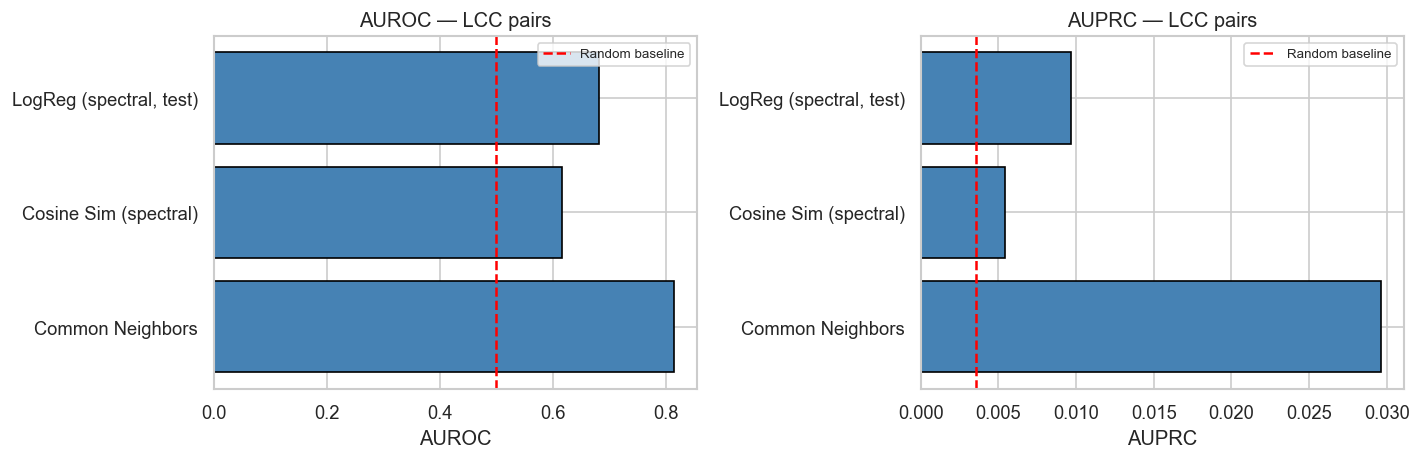

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
lcc_rows = summary[summary['Scope'] == 'LCC only']

for ax, metric in zip(axes, ['AUROC', 'AUPRC']):
    ax.barh(lcc_rows['Method'], lcc_rows[metric], color='steelblue', edgecolor='black')
    ax.axvline(0.5 if metric == 'AUROC' else random_auprc,
               color='red', linestyle='--', label='Random baseline')
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — LCC pairs')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
K = 20
top_idx = np.argsort(y_prob_all)[::-1][:K]
rows = []
for rank, idx in enumerate(top_idx, 1):
    cid, did = pair_list[idx]
    rows.append({
        'Rank':      rank,
        'Compound':  name_lookup.get(('Compound', cid), cid),
        'Disease':   name_lookup.get(('Disease',  did), did),
        'Score':     round(float(y_prob_all[idx]), 4),
        'Known CtD': '✓' if (cid, did) in ctd_pairs else '',
    })

print(f'Top-{K} predictions — Logistic Regression (spectral embeddings, all LCC pairs)')
pd.DataFrame(rows)

Top-20 predictions — Logistic Regression (spectral embeddings, all LCC pairs)


,Rank,Compound,Disease,Score,Known CtD
0,1,Cromoglicic acid,atopic dermatitis,0.9332,
1,2,Anagrelide,atopic dermatitis,0.9282,
2,3,Vindesine,atopic dermatitis,0.9269,
3,4,Metrizamide,atopic dermatitis,0.9246,
4,5,Estradiol valerate/Dienogest,atopic dermatitis,0.9227,
5,6,Simvastatin,atopic dermatitis,0.9167,
6,7,Cromoglicic acid,intracranial aneurysm,0.9162,
7,8,Diloxanide,atopic dermatitis,0.9117,
8,9,Anagrelide,intracranial aneurysm,0.9100,
9,10,Vindesine,intracranial aneurysm,0.9084,
